# Study 5 Analysis
### Python replication of `Study_5_code.do` (Stata)

**Paper**: Pennycook et al. (2021, *Nature*) — "Shifting attention to accuracy can reduce misinformation online"

**Research question**: Can a brief "accuracy nudge" — asking people to judge the accuracy of a single unrelated headline — reduce willingness to share misinformation on social media?

| Condition | Pre-task |
|-----------|----------|
| 1 — Passive Control | None |
| 2 — Active Control | Rate how *funny* a neutral headline is |
| 3 — Treatment | Rate how *accurate* a neutral headline is |
| 4 — Importance Treatment | Agree/disagree: "It is important to only share accurate content" |

**Primary outcome**: `sm` — sharing willingness on a continuous 0–1 scale (rescaled from a 6-point Likert item).
The key finding is the **interaction** between condition and headline veracity: does the nudge widen the true/false sharing gap?

## 1. Setup — Imports & Helper Functions

### Imports & global settings

In [117]:
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import warnings
warnings.filterwarnings('ignore')

# Condition colour palette (matches paper figure style)
COND_COLORS = {
    1: '#F4CCCC',   # Passive Control  — light pink
    2: '#E06666',   # Active Control   — dark red
    3: '#CFE2F3',   # Treatment        — light blue
    4: '#6FA8DC',   # Importance Treatment — medium blue
}
COND_LABELS = {
    1: 'Passive Control',
    2: 'Active Control',
    3: 'Treatment',
    4: 'Importance Treatment',
}

DATA_DIR   = "./"          # input data location (Study_5_data.csv)
OUTPUT_DIR = "./output/"   # all outputs: figures (PNG) and exported CSV
import os; os.makedirs(OUTPUT_DIR, exist_ok=True)

### Helper functions

**`ttest_report`** — Welch's independent-samples t-test (does not assume equal variances).

**`two_way_cluster_ols`** — OLS regression with two-way clustered standard errors (Cameron, Gelbach & Miller 2011).
Clustering simultaneously by participant (`id`) and headline (`item_num`) corrects for the panel structure of the data:
each participant rates multiple headlines, and each headline is rated by many participants.
The formula is:

$$\hat{V}_{\text{2-way}} = \hat{V}_{\text{cluster by id}} + \hat{V}_{\text{cluster by item}} - \hat{V}_{\text{HC1}}$$

This is the Python equivalent of Stata's `cluster2` command used in the original `.do` file.

In [118]:
def ttest_report(label, group0, group1):
    """Independent-samples Welch t-test; prints means, t, p."""
    g0, g1 = group0.dropna(), group1.dropna()
    if len(g0) < 2 or len(g1) < 2:
        print(f"  {label}: insufficient data"); return
    t, p = stats.ttest_ind(g0, g1)
    print(f"  {label}: n0={len(g0)}, mean0={g0.mean():.4f} | "
          f"n1={len(g1)}, mean1={g1.mean():.4f} | t={t:.4f}, p={p:.4f}")


def two_way_cluster_ols(formula, data, cluster1, cluster2_col, label=""):
    """OLS with two-way clustered SEs (Cameron, Gelbach & Miller 2011)."""
    data = data.reset_index(drop=True)
    r1  = smf.ols(formula, data=data).fit(cov_type='cluster', cov_kwds={'groups': data[cluster1]})
    r2  = smf.ols(formula, data=data).fit(cov_type='cluster', cov_kwds={'groups': data[cluster2_col]})
    r0  = smf.ols(formula, data=data).fit(cov_type='HC1')
    model = smf.ols(formula, data=data).fit()

    vcov_2way = r1.cov_params() + r2.cov_params() - r0.cov_params()
    se     = np.sqrt(np.diag(vcov_2way))
    t_vals = model.params / se
    p_vals = 2 * stats.t.sf(np.abs(t_vals), df=model.df_resid)

    summary = pd.DataFrame({'coef': model.params, 'se': se, 't': t_vals, 'p': p_vals})
    if label:
        print(f"\n{'='*60}\nREGRESSION: {label}\n{'='*60}")
    print(summary.to_string(float_format=lambda x: f"{x:.4f}"))
    print(f"  N={int(model.nobs)}, R²={model.rsquared:.4f}")
    return model, summary

## 2. Data Loading & Sample Description

**Steps in this section**:
1. Load raw CSV and apply exclusions (did not finish survey; failed Facebook check)
2. Print descriptive statistics: N, age, sex, sharer breakdown
3. Chi-square test — verify that sharer proportions are balanced across conditions (ruling out selection bias from random assignment)

**Exclusion criteria**:
- `didnt_finish == 1` — incomplete survey
- `fb == 2` — failed bot/attention check

**Chi-square null hypothesis H₀**: The proportion of "sharers" (`socialmedia_chk == 1`) is equal across all four conditions.
If p > 0.05, random assignment was successful and groups are comparable.

In [119]:
# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_DIR + "Study_5_data.csv", low_memory=False)
df.columns = df.columns.str.lower()
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['id'] = np.arange(1, len(df) + 1)
df['didnt_finish'] = df['socialmedia_chk'].isna().astype(int)
df.rename(columns={'gender': 'sex'}, inplace=True)

# Stata: sum id
print("=== sum id (full sample) ===")
print(f"  Obs={len(df)},  Mean={df['id'].mean():.4f},  "
      f"Std Dev={df['id'].std():.4f},  Min={df['id'].min()},  Max={df['id'].max()}")

# ── Stata: table didnt_finish fb ──────────────────────────────────────────────
print("\n=== table didnt_finish × fb ===")
ct_excl = pd.crosstab(df['didnt_finish'], df['fb'], margins=False)
print(ct_excl.to_string())

# ── Exclusions ────────────────────────────────────────────────────────────────
df = df[(df['didnt_finish'] != 1) & (df['fb'] != 2)].copy()
print(f"\nAfter exclusions: {len(df)} obs deleted → N = {len(df)}")

# Stata: sum id age
print("\n=== sum id age (after exclusions) ===")
for v in ['id', 'age']:
    s = df[v]
    print(f"  {v:4s}:  Obs={s.count()},  Mean={s.mean():.5f},  "
          f"Std Dev={s.std():.5f},  Min={s.min()},  Max={s.max()}")

# Stata: table sex
print("\n=== table sex ===")
print(df['sex'].value_counts().sort_index().rename("Freq").to_string())

# Stata: sum id if sex==.
n_miss_sex = df['sex'].isna().sum()
print(f"\n=== sum id if sex==. ===")
print(f"  Obs = {n_miss_sex}  (0 = no missing sex values)")

# Stata: table socialmedia_chk
print("\n=== table socialmedia_chk ===")
print(df['socialmedia_chk'].value_counts().sort_index().rename("Freq").to_string())

# Stata: sum id age if socialmedia_chk==1
sharers = df[df['socialmedia_chk'] == 1].copy()
print("\n=== sum id age if socialmedia_chk==1 (sharers) ===")
for v in ['id', 'age']:
    s = sharers[v]
    print(f"  {v:4s}:  Obs={s.count()},  Mean={s.mean():.5f},  "
          f"Std Dev={s.std():.5f},  Min={s.min()},  Max={s.max()}")

# Stata: table sex if socialmedia_chk==1
print("\n=== table sex if socialmedia_chk==1 ===")
print(sharers['sex'].value_counts().sort_index().rename("Freq").to_string())

# Stata: sum id if sex==. & socialmedia_chk==1
n_miss_sex_sh = sharers['sex'].isna().sum()
print(f"\n=== sum id if sex==. & socialmedia_chk==1 ===")
print(f"  Obs = {n_miss_sex_sh}  (0 = no missing sex values among sharers)")

# ── Chi-square test: sharer balance across conditions ─────────────────────────
df['demrep'] = (1 + (df['demrep_c'] > 3)).where(df['demrep_c'].notna(), other=np.nan)
df['socialmedia_chk1'] = np.where(
    df['socialmedia_chk'].isna(), np.nan,
    (df['socialmedia_chk'] == 1).astype(float)
)

print("\n=== tabulate socialmedia_chk1 × condition (chi2) ===")
ct = pd.crosstab(df['socialmedia_chk1'], df['condition'])
print(ct.to_string())
chi2_val, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f"\n  Pearson chi2({dof}) = {chi2_val:.4f},  p = {p_chi:.4f}")
print("  →", "Balanced across conditions ✓" if p_chi > 0.05 else "Imbalanced — check assignment")

=== sum id (full sample) ===
  Obs=1628,  Mean=814.5000,  Std Dev=470.1074,  Min=1,  Max=1628

=== table didnt_finish × fb ===
fb             1.0  2.0
didnt_finish           
0             1287    0
1              101  236

After exclusions: 1287 obs deleted → N = 1287

=== sum id age (after exclusions) ===
  id  :  Obs=1287,  Mean=749.86247,  Std Dev=426.75695,  Min=1,  Max=1627
  age :  Obs=1287,  Mean=45.45066,  Std Dev=16.96114,  Min=18,  Max=87

=== table sex ===
sex
1    626
2    661

=== sum id if sex==. ===
  Obs = 0  (0 = no missing sex values)

=== table socialmedia_chk ===
socialmedia_chk
1.0    671
2.0    605
3.0     11

=== sum id age if socialmedia_chk==1 (sharers) ===
  id  :  Obs=671,  Mean=732.69896,  Std Dev=421.03655,  Min=1,  Max=1506
  age :  Obs=671,  Mean=44.37258,  Std Dev=16.29407,  Min=18,  Max=84

=== table sex if socialmedia_chk==1 ===
sex
1    333
2    338

=== sum id if sex==. & socialmedia_chk==1 ===
  Obs = 0  (0 = no missing sex values among sharers)

=

## 3. Reshape: Wide → Long Format

The raw data is **wide format** (one row per participant, one column per headline).
Regression requires **long format** (one row per participant × headline observation).

**Key variables created**:

| Variable | Description |
|----------|-------------|
| `real` | 0 = false headline, 1 = true headline |
| `sm` | Sharing willingness rescaled to [0, 1] via `(raw − 1) / 5` |
| `item_num` | 1–10 = false headlines; true headlines get **+10** (→ 11–20) to avoid index collisions in two-way clustering |
| `Bsm` | Binary share intent: `round(sm)` (0 or 1) |
| `treatment` | Dummy = 1 if condition == 3 |
| `importance` | Dummy = 1 if condition == 4 |

> **Critical**: the +10 shift on `item_num` for true headlines must **not** be undone until the MATLAB export step.
> Undoing it early merges false and true items and corrupts the item-level analysis (gives r ≈ 0.27 instead of the correct r = 0.61).

In [120]:
# Identify fake{n}_3 and real{n}_3 columns
fake_sm_cols, real_sm_cols = {}, {}
for col in df.columns:
    m = re.match(r'^fake(\d+)_3$', col)
    if m: fake_sm_cols[int(m.group(1))] = col
    m = re.match(r'^real(\d+)_3$', col)
    if m: real_sm_cols[int(m.group(1))] = col

all_items = sorted(set(list(fake_sm_cols.keys()) + list(real_sm_cols.keys())))
print(f"False headline columns: {sorted(fake_sm_cols.keys())}")
print(f"True  headline columns: {sorted(real_sm_cols.keys())}")

# Build long-format rows
rows = []
for _, row in df.iterrows():
    for item_n in all_items:
        base = {
            'id': row['id'], 'condition': row.get('condition', np.nan),
            'demrep': row.get('demrep', np.nan), 'demrep_c': row.get('demrep_c', np.nan),
            'age': row.get('age', np.nan), 'sex': row.get('sex', np.nan),
            'fb': row.get('fb', np.nan),
            'socialmedia_chk': row.get('socialmedia_chk', np.nan),
            'socialmedia_chk1': row.get('socialmedia_chk1', np.nan),
            'item_num': item_n,
        }
        r_fake = {**base, 'sm': row.get(fake_sm_cols.get(item_n, '__'), np.nan), 'real': 0}
        r_real = {**base, 'sm': row.get(real_sm_cols.get(item_n, '__'), np.nan), 'real': 1}
        rows.extend([r_fake, r_real])

long = pd.DataFrame(rows)

# Political concordance
long['prorep'] = (long['item_num'] <= 5).astype(float)
long['politically_concordant'] = (
    ((long['prorep'] == 1) & (long['demrep'] == 2)) |
    ((long['prorep'] == 0) & (long['demrep'] == 1))
).astype(float)

# Rescale sm to [0, 1]
long['sm'] = (long['sm'] - 1) / 5

# Shift true-headline item_num by +10
long.loc[long['real'] == 1, 'item_num'] = long.loc[long['real'] == 1, 'item_num'] + 10

long['Bsm']       = long['sm'].round()
long['treatment']  = (long['condition'] == 3).astype(float)
long['importance'] = (long['condition'] == 4).astype(float)

# Sharers subset (used in most analyses)
sharers_long = long[long['socialmedia_chk'] == 1].copy()

print(f"Long-format rows: {len(long)}  "
      f"({len(df)} participants × {len(all_items)} items × 2 veracity types)")
print(f"Sharers subset rows: {len(sharers_long)}")
long[['id','item_num','real','condition','sm','Bsm']].head(6)

False headline columns: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
True  headline columns: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Long-format rows: 25740  (1287 participants × 10 items × 2 veracity types)
Sharers subset rows: 13420


,id,item_num,real,condition,sm,Bsm
0,1.0,1,0,4.0,0.2,0.0
1,1.0,11,1,4.0,0.2,0.0
2,1.0,2,0,4.0,0.4,0.0
3,1.0,12,1,4.0,0.2,0.0
4,1.0,3,0,4.0,0.0,0.0
5,1.0,13,1,4.0,0.2,0.0


## 4. Descriptive Figures

### Figure 2c — Mean Sharing Rate by Condition and Veracity

Bar chart of mean binary sharing rate (`Bsm`) for false and true headlines across the four conditions.
Error bars are **95% CIs from two-way clustered standard errors** (clustering by participant and headline simultaneously).

`mean_ci95_clustered` fits an intercept-only OLS model so the intercept equals the group mean,
then applies the Cameron-Gelbach-Miller formula to get the clustered SE → CI half-width = 1.96 × SE.

### Extended Data Figure 3 — Full Distribution of Sharing Intentions

The same data without binary discretisation: shows the complete frequency distribution across all 6 response categories.
Stata equivalent: `tabulate sm condition if real==0/1` — the `.do` file only tabulates, does not plot.

| sm value | Response label |
|----------|---------------|
| 0.0 | Extremely unlikely |
| 0.2 | Moderately unlikely |
| 0.4 | Slightly unlikely |
| 0.6 | Slightly likely |
| 0.8 | Moderately likely |
| 1.0 | Extremely likely |

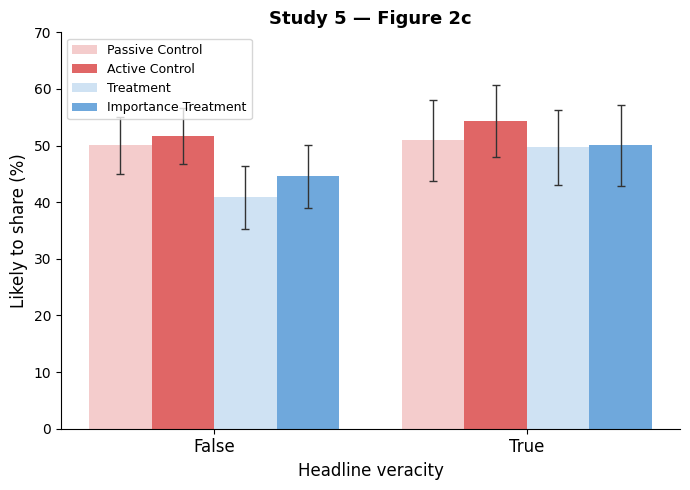

Saved: Figure_2c_Study5.png

Mean sharing rate (%):
                      False (%)  True (%)  True − False (pp)
Passive Control            50.0      50.9                0.9
Active Control             51.6      54.3                2.7
Treatment                  40.8      49.7                8.9
Importance Treatment       44.5      50.0                5.5


In [121]:
def mean_ci95_clustered(subset, outcome='Bsm', cluster1='id', cluster2_col='item_num'):
    """Mean ± 95% CI half-width using two-way clustered SEs."""
    sub = subset[[outcome, cluster1, cluster2_col]].dropna()
    if len(sub) < 3:
        return sub[outcome].mean(), 0
    r1 = smf.ols(f'{outcome} ~ 1', data=sub).fit(cov_type='cluster', cov_kwds={'groups': sub[cluster1]})
    r2 = smf.ols(f'{outcome} ~ 1', data=sub).fit(cov_type='cluster', cov_kwds={'groups': sub[cluster2_col]})
    r0 = smf.ols(f'{outcome} ~ 1', data=sub).fit(cov_type='HC1')
    v_2way = (r1.cov_params().values[0,0] + r2.cov_params().values[0,0]
              - r0.cov_params().values[0,0])
    se = np.sqrt(max(v_2way, 0))
    mean_val = smf.ols(f'{outcome} ~ 1', data=sub).fit().params['Intercept']
    return mean_val, 1.96 * se

# ── Figure 2c ─────────────────────────────────────────────────────────────────
conditions = [1, 2, 3, 4]
bar_w, group_gap = 0.18, 0.9
x_centers = np.array([0, group_gap])

fig, ax = plt.subplots(figsize=(7, 5))
for i, cond in enumerate(conditions):
    offsets = x_centers + (i - (len(conditions) - 1) / 2) * bar_w
    means, errs = [], []
    for v in [0, 1]:
        subset = sharers_long[(sharers_long['condition'] == cond) & (sharers_long['real'] == v)]
        m, e = mean_ci95_clustered(subset)
        means.append(m * 100); errs.append(e * 100)
    ax.bar(offsets, means, width=bar_w, color=COND_COLORS[cond], label=COND_LABELS[cond],
           yerr=errs, capsize=3, error_kw=dict(elinewidth=1, ecolor='#333333'))

ax.set_xticks(x_centers)
ax.set_xticklabels(['False', 'True'], fontsize=12)
ax.set_xlabel('Headline veracity', fontsize=12)
ax.set_ylabel('Likely to share (%)', fontsize=12)
ax.set_title('Study 5 — Figure 2c', fontsize=13, fontweight='bold')
ax.set_ylim(0, 70)
ax.legend(fontsize=9, frameon=True, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(DATA_DIR + '/output/Figure_2c_Study5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Figure_2c_Study5.png")

# Print mean table
tbl = sharers_long.groupby(['condition', 'real'])['Bsm'].mean().unstack() * 100
tbl.index = [COND_LABELS[c] for c in tbl.index]
tbl.columns = ['False (%)', 'True (%)']
tbl['True − False (pp)'] = tbl['True (%)'] - tbl['False (%)']
print("\nMean sharing rate (%):")
print(tbl.to_string(float_format=lambda x: f"{x:.1f}"))

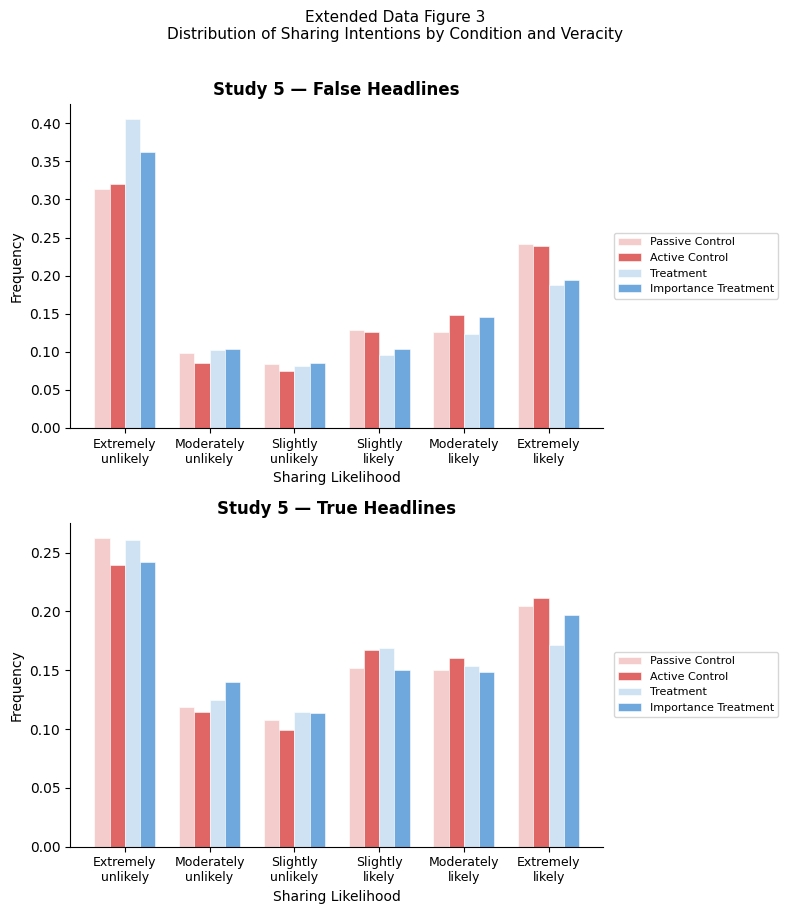

Saved: ExtDataFig3_Study5.png


In [122]:
# ── Extended Data Figure 3 ───────────────────────────────────────────────────
SM_VALS   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
SM_LABELS = ['Extremely\nunlikely', 'Moderately\nunlikely', 'Slightly\nunlikely',
             'Slightly\nlikely',   'Moderately\nlikely',   'Extremely\nlikely']

sharers_long_copy = sharers_long.copy()
sharers_long_copy['sm_round'] = sharers_long_copy['sm'].round(1)

fig, axes = plt.subplots(2, 1, figsize=(8, 9))
for ax, real_val, title in zip(axes, [0, 1],
                                ['Study 5 — False Headlines', 'Study 5 — True Headlines']):
    subset = sharers_long_copy[sharers_long_copy['real'] == real_val]
    x = np.arange(len(SM_VALS))
    for i, cond in enumerate([1, 2, 3, 4]):
        grp   = subset[subset['condition'] == cond]
        total = len(grp)
        freqs = [(grp['sm_round'] == v).sum() / total if total > 0 else 0 for v in SM_VALS]
        offset = (i - 1.5) * 0.18
        ax.bar(x + offset, freqs, width=0.18, color=COND_COLORS[cond],
               label=COND_LABELS[cond], edgecolor='white', linewidth=0.4)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=6)
    ax.set_xticks(x)
    ax.set_xticklabels(SM_LABELS, fontsize=9)
    ax.set_xlabel('Sharing Likelihood', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_ylim(0, None)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, frameon=True, loc='center left',
              bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

fig.suptitle('Extended Data Figure 3\nDistribution of Sharing Intentions by Condition and Veracity',
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(DATA_DIR + '/output/ExtDataFig3_Study5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ExtDataFig3_Study5.png")

## 5. Main Analysis — Table S4 (Two-Way Clustered OLS)

Three regressions, all using two-way clustered standard errors (by participant `id` and headline `item_num`).

### 5a. Passive Control vs Active Control
**Model**: `sm ~ C(condition) * real`  |  Sample: sharers only, conditions 1 and 2

Tests whether doing *any* warm-up task (judging funniness) changes the true/false sharing gap.
The **interaction** `C(condition)[T.2]:real` is the key term.
If non-significant → the active control does not affect discernment → ruling out a generic "task demand" explanation.

---

### 5b. Treatment & Importance vs Pooled Control — Core Regression
**Model**: `sm ~ treatment * real + importance * real`  |  Sample: sharers only

The baseline is the **pooled control** (conditions 1 + 2 combined).

| Coefficient | Meaning |
|-------------|---------|
| `real` | True/false gap in the control group |
| `treatment:real` | **Key**: does the accuracy nudge widen the true/false gap? |
| `importance:real` | Same for the importance treatment |
| `treatment` | Nudge effect on false news alone |
| `treatment + treatment:real` | Net nudge effect on true news |

**Paper reports**: treatment × real: b = 0.054, F = 11.98, p = 0.0005; importance × real: b = 0.038, F = 9.76, p = 0.0018

---

### 5c. Robustness Check — All Participants
Repeat 5a and 5b on the **full sample** (not just self-reported sharers) to verify the effect is not an artefact of the sharers restriction.

In [123]:
# ── 5a. Passive vs Active Control (sharers only) ──────────────────────────────
sub_ctrl = sharers_long[sharers_long['condition'] < 3].dropna(subset=['sm','condition','real'])
two_way_cluster_ols("sm ~ C(condition) * real", sub_ctrl,
                    'id', 'item_num', "5a: Passive vs Active Control — sharers only")


REGRESSION: 5a: Passive vs Active Control — sharers only
                           coef     se       t      p
Intercept                0.4769 0.0227 20.9986 0.0000
C(condition)[T.2.0]      0.0061 0.0303  0.2001 0.8414
real                     0.0081 0.0262  0.3102 0.7565
C(condition)[T.2.0]:real 0.0155 0.0120  1.2833 0.1994
  N=6776, R²=0.0008


(<statsmodels.regression.linear_model.RegressionResultsWrapper at 0x13d82cc50>,
                               coef        se          t             p
 Intercept                 0.476875  0.022710  20.998635  6.779239e-95
 C(condition)[T.2.0]       0.006060  0.030291   0.200071  8.414312e-01
 real                      0.008122  0.026188   0.310154  7.564537e-01
 C(condition)[T.2.0]:real  0.015454  0.012042   1.283264  1.994435e-01)

In [124]:
# ── 5b. Treatment & Importance vs Pooled Control (sharers only) ───────────────
sub_s = sharers_long.dropna(subset=['sm','treatment','importance','real'])
mdl, smry = two_way_cluster_ols(
    "sm ~ treatment * real + importance * real",
    sub_s, 'id', 'item_num',
    "5b: Treatment & Importance vs Pooled Control — sharers only"
)

b_real     = mdl.params.get('real', 0)
b_tre      = mdl.params.get('treatment', 0)
b_imp      = mdl.params.get('importance', 0)
b_treXreal = mdl.params.get('treatment:real', 0)
b_impXreal = mdl.params.get('importance:real', 0)

print("\n  Simple Effects:")
print(f"    True/false gap in control:                {b_real:+.4f}")
print(f"    True/false gap in Treatment:              {b_real + b_treXreal:+.4f}")
print(f"    True/false gap in Importance Treatment:   {b_real + b_impXreal:+.4f}")
print(f"    Treatment effect on false headlines:      {b_tre:+.4f}")
print(f"    Treatment net effect on true headlines:   {b_tre + b_treXreal:+.4f}")
print(f"    Importance effect on false headlines:     {b_imp:+.4f}")
print(f"    Importance net effect on true headlines:  {b_imp + b_impXreal:+.4f}")


REGRESSION: 5b: Treatment & Importance vs Pooled Control — sharers only
                   coef     se       t      p
Intercept        0.4801 0.0160 30.0368 0.0000
treatment       -0.0815 0.0261 -3.1248 0.0018
real             0.0163 0.0234  0.6967 0.4860
treatment:real   0.0542 0.0157  3.4617 0.0005
importance      -0.0504 0.0274 -1.8388 0.0660
importance:real  0.0376 0.0120  3.1247 0.0018
  N=13340, R²=0.0069

  Simple Effects:
    True/false gap in control:                +0.0163
    True/false gap in Treatment:              +0.0705
    True/false gap in Importance Treatment:   +0.0539
    Treatment effect on false headlines:      -0.0815
    Treatment net effect on true headlines:   -0.0273
    Importance effect on false headlines:     -0.0504
    Importance net effect on true headlines:  -0.0128


In [125]:
# ── 5c. Robustness: All Participants ─────────────────────────────────────────
sub_ctrl_all = long[long['condition'] < 3].dropna(subset=['sm','condition','real'])
two_way_cluster_ols("sm ~ C(condition) * real", sub_ctrl_all,
                    'id', 'item_num', "5c: Passive vs Active Control — all participants")

sub_all = long.dropna(subset=['sm','treatment','importance','real'])
mdl_a, _ = two_way_cluster_ols(
    "sm ~ treatment * real + importance * real",
    sub_all, 'id', 'item_num',
    "5c: Treatment & Importance vs Control — all participants"
)
b_r = mdl_a.params.get('real',0); b_t = mdl_a.params.get('treatment',0)
b_i = mdl_a.params.get('importance',0)
b_tr = mdl_a.params.get('treatment:real',0); b_ir = mdl_a.params.get('importance:real',0)
print("\n  Simple Effects (all participants):")
print(f"    True/false gap in control:               {b_r:+.4f}")
print(f"    True/false gap in Treatment:             {b_r + b_tr:+.4f}")
print(f"    Treatment effect on false headlines:     {b_t:+.4f}")
print(f"    Importance effect on false headlines:    {b_i:+.4f}")


REGRESSION: 5c: Passive vs Active Control — all participants
                           coef     se       t      p
Intercept                0.3588 0.0166 21.5651 0.0000
C(condition)[T.2.0]      0.0179 0.0223  0.8045 0.4211
real                     0.0111 0.0206  0.5410 0.5885
C(condition)[T.2.0]:real 0.0086 0.0066  1.2969 0.1947
  N=12847, R²=0.0013

REGRESSION: 5c: Treatment & Importance vs Control — all participants
                   coef     se       t      p
Intercept        0.3679 0.0127 28.9371 0.0000
treatment       -0.0500 0.0185 -2.7044 0.0068
real             0.0154 0.0212  0.7282 0.4665
treatment:real   0.0466 0.0091  5.1063 0.0000
importance      -0.0097 0.0193 -0.5006 0.6166
importance:real  0.0291 0.0063  4.5929 0.0000
  N=25587, R²=0.0039

  Simple Effects (all participants):
    True/false gap in control:               +0.0154
    True/false gap in Treatment:             +0.0621
    Treatment effect on false headlines:     -0.0500
    Importance effect on false headli

## 6. Mechanism Analysis — Figure 3c & Extended Data Figure 4

**Logic**: If inattention (not ignorance or motivated reasoning) drives misinformation sharing,
then priming accuracy should have the *largest* effect on headlines that participants could
already identify as false if they stopped to think.
In other words: the treatment effect per headline should correlate *positively* with that
headline's pre-rated perceived accuracy.

**Three steps**:
1. Merge pre-test ratings (`plausible`, `funny`, `goodrep`, `familiar`) into the long-format data
2. Collapse to item level (20 rows) → compute treatment effects → Pearson correlation → **Figure 3c**
3. Plot treatment effects vs all pre-test variables → **Extended Data Figure 4** (2 × 3 scatter matrix)

> `item_num` encoding (1–10 = false, 11–20 = true) is kept intact throughout steps 1–3.
> It is only reversed in Section 7 (MATLAB export).

In [126]:
# ── Step 1: Merge pre-test ratings ───────────────────────────────────────────
# Keys match item_num encoding: 1-10 = false headlines, 11-20 = true headlines.
funny_vals = {
    1:2.790909, 2:2.941748, 3:2.849558, 4:2.268519, 5:3.823009,
    6:3.954955, 7:3.564815, 8:3.103774, 9:4.160377, 10:3.235294,
    11:2.61165, 12:2.781818, 13:3.311321, 14:2.690909, 15:3.46729,
    16:3.698113, 17:2.90566, 18:2.245283, 19:2.839286, 20:2.56,
}
funnyDR_vals = {
    (1,1):2.68, (2,1):2.771429, (3,1):2.822785, (4,1):2.191781, (5,1):3.47561,
    (6,1):3.8125, (7,1):3.739726, (8,1):3.239437, (9,1):4.066667, (10,1):3.442857,
    (11,1):2.552632, (12,1):2.820896, (13,1):3.162162, (14,1):2.540541, (15,1):3.447368,
    (16,1):3.768116, (17,1):2.944444, (18,1):2.078947, (19,1):2.972603, (20,1):2.542857,
    (1,2):3.028571, (2,2):3.30303, (3,2):2.911765, (4,2):2.428571, (5,2):4.741935,
    (6,2):4.322581, (7,2):3.2, (8,2):2.828571, (9,2):4.387097, (10,2):2.78125,
    (11,2):2.777778, (12,2):2.72093, (13,2):3.65625, (14,2):3, (15,2):3.516129,
    (16,2):3.567568, (17,2):2.823529, (18,2):2.666667, (19,2):2.589744, (20,2):2.6,
}
plausible_vals = {
    1:2.372727, 2:2.271845, 3:1.646018, 4:2.046296, 5:2.20354,
    6:1.603604, 7:2.268519, 8:2.09434, 9:2.084906, 10:3.588235,
    11:4.902913, 12:4.872727, 13:5.377358, 14:5.8, 15:4.682243,
    16:4.962264, 17:4.528302, 18:5.377358, 19:5.044643, 20:5.44,
}
plausibleDR_vals = {
    (1,1):2.133333, (2,1):1.771429, (3,1):1.56962, (4,1):1.684932, (5,1):2.195122,
    (6,1):1.7875, (7,1):2.315068, (8,1):2.28169, (9,1):2.266667, (10,1):3.9,
    (11,1):4.894737, (12,1):4.716418, (13,1):5.27027, (14,1):5.756757, (15,1):4.394737,
    (16,1):5.333333, (17,1):4.972222, (18,1):5.5, (19,1):5.452055, (20,1):5.671429,
    (1,2):2.885714, (2,2):3.333333, (3,2):1.823529, (4,2):2.8, (5,2):2.225806,
    (6,2):1.129032, (7,2):2.171429, (8,2):1.714286, (9,2):1.645161, (10,2):2.90625,
    (11,2):4.925926, (12,2):5.116279, (13,2):5.625, (14,2):5.888889, (15,2):5.387097,
    (16,2):4.27027, (17,2):3.588235, (18,2):5.066667, (19,2):4.282051, (20,2):4.9,
}
goodrep_vals = {
    1:4.081818, 2:4.067961, 3:4.19469, 4:4.222222, 5:3.99115,
    6:1.711712, 7:1.722222, 8:2.226415, 9:1.933962, 10:1.813725,
    11:3.951456, 12:3.754545, 13:3.754717, 14:4.063636, 15:3.831776,
    16:2.09434, 17:1.858491, 18:2.113208, 19:2.017857, 20:2.15,
}
goodrepDR_vals = {
    (1,1):4, (2,1):4.142857, (3,1):4.265823, (4,1):4.30137, (5,1):3.914634,
    (6,1):1.7, (7,1):1.780822, (8,1):2.267606, (9,1):2.04, (10,1):1.857143,
    (11,1):3.947368, (12,1):3.641791, (13,1):3.635135, (14,1):4.013514, (15,1):3.723684,
    (16,1):2.028986, (17,1):1.847222, (18,1):1.947368, (19,1):2.013699, (20,1):2.1,
    (1,2):4.257143, (2,2):3.909091, (3,2):4.029412, (4,2):4.057143, (5,2):4.193548,
    (6,2):1.741935, (7,2):1.6, (8,2):2.142857, (9,2):1.677419, (10,2):1.71875,
    (11,2):3.962963, (12,2):3.930233, (13,2):4.03125, (14,2):4.166667, (15,2):4.096774,
    (16,2):2.216216, (17,2):1.882353, (18,2):2.533333, (19,2):2.025641, (20,2):2.266667,
}
familiar_vals = {
    1:2.890909, 2:2.834951, 3:2.955752, 4:2.851852, 5:2.840708,
    6:2.936937, 7:2.87037, 8:2.801887, 9:2.820755, 10:2.882353,
    11:2.873786, 12:2.8, 13:2.320755, 14:2.263636, 15:2.663551,
    16:2.509434, 17:2.698113, 18:2.584906, 19:2.6875, 20:2.46,
}
familiarDR_vals = {
    (1,1):2.88, (2,1):2.842857, (3,1):2.974684, (4,1):2.876712, (5,1):2.829268,
    (6,1):2.95, (7,1):2.90411, (8,1):2.830986, (9,1):2.813333, (10,1):2.914286,
    (11,1):2.868421, (12,1):2.910448, (13,1):2.418919, (14,1):2.297297, (15,1):2.736842,
    (16,1):2.434783, (17,1):2.680556, (18,1):2.592105, (19,1):2.657534, (20,1):2.442857,
    (1,2):2.914286, (2,2):2.818182, (3,2):2.911765, (4,2):2.8, (5,2):2.870968,
    (6,2):2.903226, (7,2):2.8, (8,2):2.742857, (9,2):2.83871, (10,2):2.8125,
    (11,2):2.888889, (12,2):2.627907, (13,2):2.09375, (14,2):2.194444, (15,2):2.483871,
    (16,2):2.648649, (17,2):2.735294, (18,2):2.566667, (19,2):2.74359, (20,2):2.5,
}

long['funny']      = long['item_num'].map(funny_vals)
long['plausible']  = long['item_num'].map(plausible_vals)
long['goodrep']    = long['item_num'].map(goodrep_vals)
long['familiar']   = long['item_num'].map(familiar_vals)

long['funnyDR']    = long.apply(lambda r: funnyDR_vals.get(
    (int(r['item_num']), int(r['demrep'])) if pd.notna(r['demrep']) else (-1,-1), np.nan), axis=1)
long['plausibleDR']= long.apply(lambda r: plausibleDR_vals.get(
    (int(r['item_num']), int(r['demrep'])) if pd.notna(r['demrep']) else (-1,-1), np.nan), axis=1)
long['goodrepDR']  = long.apply(lambda r: goodrepDR_vals.get(
    (int(r['item_num']), int(r['demrep'])) if pd.notna(r['demrep']) else (-1,-1), np.nan), axis=1)
long['familiarDR'] = long.apply(lambda r: familiarDR_vals.get(
    (int(r['item_num']), int(r['demrep'])) if pd.notna(r['demrep']) else (-1,-1), np.nan), axis=1)

long['concordant']   = (long['goodrep']   * (long['demrep'] == 2)
                        + (6 - long['goodrep'])   * (long['demrep'] == 1))
long['concordantDR'] = (long['goodrepDR'] * (long['demrep'] == 2)
                        + (6 - long['goodrepDR']) * (long['demrep'] == 1))

# Refresh sharers_long after adding pre-test columns
sharers_long = long[long['socialmedia_chk'] == 1].copy()
print("Pre-test ratings merged.")
long[['item_num','real','plausible','funny']].drop_duplicates('item_num').sort_values('item_num')

Pre-test ratings merged.


,item_num,real,plausible,funny
0,1,0,2.372727,2.790909
2,2,0,2.271845,2.941748
4,3,0,1.646018,2.849558
6,4,0,2.046296,2.268519
8,5,0,2.203540,3.823009
10,6,0,1.603604,3.954955
12,7,0,2.268519,3.564815
14,8,0,2.094340,3.103774
16,9,0,2.084906,4.160377
18,10,0,3.588235,3.235294


Figure 3c: r(18) = 0.6054, p = 0.0047
Paper:     r(18) = 0.61,       p = 0.005


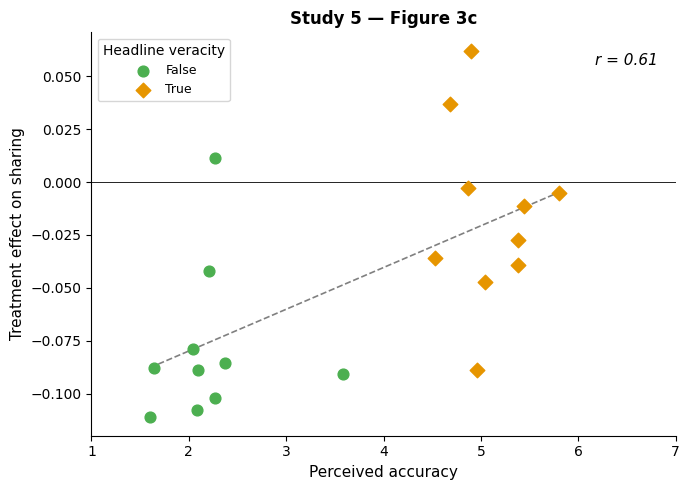

Saved: Figure_3c_Study5.png


In [127]:
# ── Step 2: Item-level collapse → Figure 3c ───────────────────────────────────
item_means = (sharers_long
              .groupby(['item_num', 'condition'])
              .agg(sm_mean=('sm', 'mean'), plausible=('plausible', 'first'),
                   funny=('funny', 'first'), real=('real', 'first'))
              .reset_index())

item_wide = item_means.pivot(index='item_num', columns='condition', values='sm_mean').reset_index()
item_wide.columns.name = None
item_wide.rename(columns={1:'sm_passive', 2:'sm_active', 3:'sm_treatment', 4:'sm_importance'},
                 inplace=True)

if 'sm_passive' in item_wide.columns:
    for col, name in [('sm_active','EActive'), ('sm_treatment','ETreatment'),
                      ('sm_importance','EImportance')]:
        if col in item_wide.columns:
            item_wide[name] = item_wide[col] - item_wide['sm_passive']

pretest = (sharers_long.groupby('item_num')
           .agg(plausible=('plausible','first'), funny=('funny','first'),
                is_true=('real','first'))
           .reset_index())
item_wide = item_wide.merge(pretest, on='item_num', how='left')

# Pearson correlation: ETreatment × plausible (Figure 3c)
sub_corr = item_wide.dropna(subset=['ETreatment', 'plausible'])
r, p_r = stats.pearsonr(sub_corr['ETreatment'], sub_corr['plausible'])
print(f"Figure 3c: r({len(sub_corr)-2}) = {r:.4f}, p = {p_r:.4f}")
print(f"Paper:     r(18) = 0.61,       p = 0.005")

is_true = sub_corr['is_true'] == 1
fig3, ax3 = plt.subplots(figsize=(7, 5))
ax3.scatter(sub_corr.loc[~is_true, 'plausible'], sub_corr.loc[~is_true, 'ETreatment'],
            color='#4CAF50', marker='o', s=60, zorder=3, label='False')
ax3.scatter(sub_corr.loc[is_true,  'plausible'], sub_corr.loc[is_true,  'ETreatment'],
            color='#E69500', marker='D', s=55, zorder=3, label='True')
m_fit, b_fit = np.polyfit(sub_corr['plausible'], sub_corr['ETreatment'], 1)
xr = np.linspace(sub_corr['plausible'].min(), sub_corr['plausible'].max(), 100)
ax3.plot(xr, m_fit*xr + b_fit, color='gray', linewidth=1.2, linestyle='--', zorder=2)
ax3.axhline(0, color='black', linewidth=0.6)
ax3.text(0.97, 0.95, f'r = {r:.2f}', transform=ax3.transAxes,
         ha='right', va='top', fontsize=11, style='italic')
ax3.set_xlabel('Perceived accuracy', fontsize=11)
ax3.set_ylabel('Treatment effect on sharing', fontsize=11)
ax3.set_title('Study 5 — Figure 3c', fontsize=12, fontweight='bold')
ax3.set_xlim(1, 7)
ax3.legend(title='Headline veracity', fontsize=9, frameon=True, loc='upper left')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
plt.tight_layout()
fig3.savefig(DATA_DIR + '/output/Figure_3c_Study5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Figure_3c_Study5.png")

Item-level correlation matrix:
             EActive  ETreatment  EImportance  plausible   funny
EActive       1.0000      0.7157       0.6613     0.2831 -0.0208
ETreatment    0.7157      1.0000       0.7754     0.6054 -0.4022
EImportance   0.6613      0.7754       1.0000     0.6901 -0.1193
plausible     0.2831      0.6054       0.6901     1.0000 -0.3732
funny        -0.0208     -0.4022      -0.1193    -0.3732  1.0000

P-values:
  EActive × ETreatment: r=0.7157, p=0.0004
  EActive × EImportance: r=0.6613, p=0.0015
  EActive × plausible: r=0.2831, p=0.2265
  EActive × funny: r=-0.0208, p=0.9305
  ETreatment × EImportance: r=0.7754, p=0.0001
  ETreatment × plausible: r=0.6054, p=0.0047
  ETreatment × funny: r=-0.4022, p=0.0788
  EImportance × plausible: r=0.6901, p=0.0008
  EImportance × funny: r=-0.1193, p=0.6164
  plausible × funny: r=-0.3732, p=0.1051


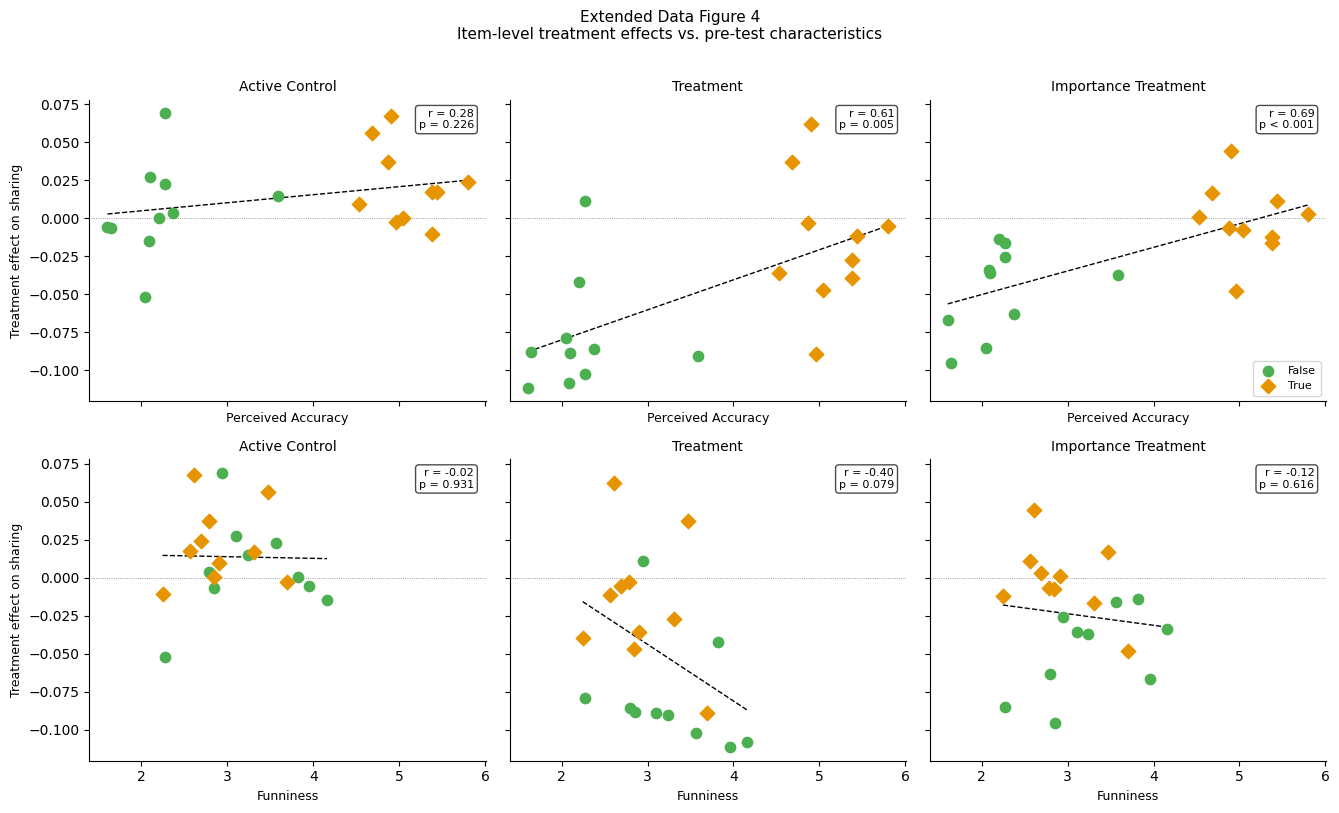

Saved: ExtDataFig4_Study5.png


In [128]:
# ── Step 3: Extended Data Figure 4 (2 × 3 scatter matrix) ────────────────────
effect_cols  = [c for c in ['EActive','ETreatment','EImportance'] if c in item_wide.columns]
pretest_cols = [c for c in ['plausible','funny']                  if c in item_wide.columns]
pretest_labels = {'plausible': 'Perceived Accuracy', 'funny': 'Funniness'}
effect_labels  = {'EActive': 'Active Control', 'ETreatment': 'Treatment',
                  'EImportance': 'Importance Treatment'}

# Numerical correlation matrix
corr_cols = effect_cols + pretest_cols
corr_df   = item_wide[corr_cols].dropna()
print("Item-level correlation matrix:")
print(corr_df.corr().to_string(float_format=lambda x: f"{x:.4f}"))
print("\nP-values:")
for i_c, c1 in enumerate(corr_cols):
    for c2 in corr_cols[i_c+1:]:
        sub = corr_df[[c1, c2]].dropna()
        r_v, p_v = stats.pearsonr(sub[c1], sub[c2])
        print(f"  {c1} × {c2}: r={r_v:.4f}, p={p_v:.4f}")

# Scatter plots
n_rows, n_cols = len(pretest_cols), len(effect_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5*n_cols, 4*n_rows),
                         sharex='col', sharey='row')
if n_rows == 1: axes = [axes]
if n_cols == 1: axes = [[ax] for ax in axes]

for row_i, pre in enumerate(pretest_cols):
    for col_i, eff in enumerate(effect_cols):
        ax  = axes[row_i][col_i]
        sub = item_wide[[eff, pre, 'is_true']].dropna()
        if sub.empty: ax.set_visible(False); continue

        false_pts = sub[sub['is_true'] == 0]
        true_pts  = sub[sub['is_true'] == 1]
        ax.scatter(false_pts[pre], false_pts[eff], color='#4CAF50', marker='o', s=55, label='False', zorder=3)
        ax.scatter(true_pts[pre],  true_pts[eff],  color='#E69500', marker='D', s=55, label='True',  zorder=3)

        m, b = np.polyfit(sub[pre], sub[eff], 1)
        xr   = np.linspace(sub[pre].min(), sub[pre].max(), 100)
        ax.plot(xr, m*xr + b, 'k--', linewidth=1, zorder=2)

        r_v, p_v = stats.pearsonr(sub[pre], sub[eff])
        p_str = f"p = {p_v:.3f}" if p_v >= 0.001 else "p < 0.001"
        ax.text(0.97, 0.97, f"r = {r_v:.2f}\n{p_str}", transform=ax.transAxes,
                fontsize=8, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))

        ax.axhline(0, color='grey', linewidth=0.6, linestyle=':')
        ax.set_xlabel(pretest_labels.get(pre, pre), fontsize=9)
        if col_i == 0:
            ax.set_ylabel('Treatment effect on sharing', fontsize=9)
        ax.set_title(effect_labels.get(eff, eff), fontsize=10)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        if row_i == 0 and col_i == n_cols - 1:
            ax.legend(fontsize=8, frameon=True, loc='lower right')

fig.suptitle('Extended Data Figure 4\nItem-level treatment effects vs. pre-test characteristics',
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig(DATA_DIR + '/output/ExtDataFig4_Study5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ExtDataFig4_Study5.png")

## 7. Export for MATLAB

Export the processed long-format data (sharers only, complete cases) as a CSV for downstream
model fitting and bootstrap analysis in MATLAB.

**Note**: The +10 shift on `item_num` is reversed here (true headlines return to 1–10)
to match the convention expected by the MATLAB scripts.
This is the **only** place where the shift is undone.

In [129]:
export_df = long[long['socialmedia_chk'] == 1].copy()

# Reverse the +10 shift for MATLAB (true headlines: 11-20 → 1-10)
export_df.loc[export_df['real'] == 1, 'item_num'] = (
    export_df.loc[export_df['real'] == 1, 'item_num'] - 10
)

export_df = export_df[export_df['demrep'].notna()].copy()
item_counts = export_df.groupby('id')['sm'].count()
valid_ids   = item_counts[item_counts >= 20].index
export_df   = export_df[export_df['id'].isin(valid_ids)]

out_cols   = ['real','id','item_num','condition','sm','demrep',
              'funny','funnyDR','plausible','plausibleDR',
              'familiar','familiarDR','concordant','concordantDR']
avail_cols = [c for c in out_cols if c in export_df.columns]
export_df[avail_cols].to_csv(DATA_DIR + "/output/dataS5_for_matlab_fit_bootstrap_long.csv", index=False)

print(f"Export rows: {len(export_df)}")
print(export_df.groupby('condition')['id'].nunique().rename('n_subjects'))
print(f"\nExported → {DATA_DIR}/output/dataS5_for_matlab_fit_bootstrap_long.csv")
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)

Export rows: 12220
condition
1.0    144
2.0    162
3.0    155
4.0    150
Name: n_subjects, dtype: int64

Exported → .//output/dataS5_for_matlab_fit_bootstrap_long.csv

ANALYSIS COMPLETE
